In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,ParameterGrid, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score,f1_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.svm import SVC,LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from scipy.sparse import hstack
#from gensim.models import Word2Vec

In [ ]:
# Load
df = pd.read_csv("development.csv")
dfeval = pd.read_csv("evaluation.csv")

print("=== SHAPES ===")
print("development shape:", df.shape)
print("evaluation shape:", dfeval.shape)

print("\n=== COLUMNS (dev) ===")
print(df.dtypes)

print("\n=== MISSING VALUES (dev) ===")
miss_dev = df.isna().sum().sort_values(ascending=False)
print(miss_dev)

print("\n=== MISSING VALUES (eval) ===")
miss_eval = dfeval.isna().sum().sort_values(ascending=False)
print(miss_eval)

print("\n=== UNIQUE VALUES (dev) ===")
uniq_dev = df.nunique().sort_values(ascending=False)
print(uniq_dev)

print("\n=== LABEL DISTRIBUTION (dev) ===")
label_counts = df["label"].value_counts().sort_index()
label_perc = (label_counts / len(df)).round(4)
print(pd.DataFrame({"count": label_counts, "perc": label_perc}))

print("\n=== TEXT LENGTH STATS (dev) ===")
# Safe handling for NaNs
title_len = df["title"].fillna("").str.split().str.len()
article_len = df["article"].fillna("").str.split().str.len()

print("title words:   mean =", title_len.mean().round(2),
      " | median =", title_len.median(),
      " | p95 =", int(np.percentile(title_len, 95)))
print("article words: mean =", article_len.mean().round(2),
      " | median =", article_len.median(),
      " | p95 =", int(np.percentile(article_len, 95)))

print("\n=== TEXT LENGTH BY CLASS (dev) ===")
tmp = df.copy()
tmp["title_words"] = title_len
tmp["article_words"] = article_len
by_class = tmp.groupby("label")[["title_words","article_words"]].agg(["mean","median"])
print(by_class.round(2))


=== SHAPES ===
development shape: (79997, 7)
evaluation shape: (20000, 6)

=== COLUMNS (dev) ===
Id            int64
source       object
title        object
article      object
page_rank     int64
timestamp    object
label         int64
dtype: object

=== MISSING VALUES (dev) ===
title        1
article      1
Id           0
source       0
page_rank    0
timestamp    0
label        0
dtype: int64

=== MISSING VALUES (eval) ===
article      1
Id           0
source       0
title        0
page_rank    0
timestamp    0
dtype: int64

=== UNIQUE VALUES (dev) ===
Id           79997
title        75783
article      74393
timestamp    52183
source        1359
label            7
page_rank        4
dtype: int64

=== LABEL DISTRIBUTION (dev) ===
       count    perc
label               
0      23542  0.2943
1      10588  0.1324
2      11161  0.1395
3       9977  0.1247
4       8574  0.1072
5      13053  0.1632
6       3102  0.0388

=== TEXT LENGTH STATS (dev) ===
title words:   mean = 6.99  | median

In [ ]:
for col in df.columns:
  print(col,len(df[col].unique()),len(df[col].unique())/df.shape[0])

Id 79997 1.0
source 1359 0.016988137055139567
title 75784 0.9473355250821905
article 74394 0.9299598734952561
page_rank 4 5.000187507031514e-05
timestamp 52183 0.6523119616985636
label 7 8.750328137305149e-05


In [ ]:
label_counts = df['label'].value_counts()
print("Counts of each unique label:")
display(label_counts,label_counts/df.shape[0])

Counts of each unique label:


,count
label,
0,23542
5,13053
2,11161
1,10588
3,9977
4,8574
6,3102


,count
label,
0,0.294286
5,0.163169
2,0.139518
1,0.132355
3,0.124717
4,0.107179
6,0.038776


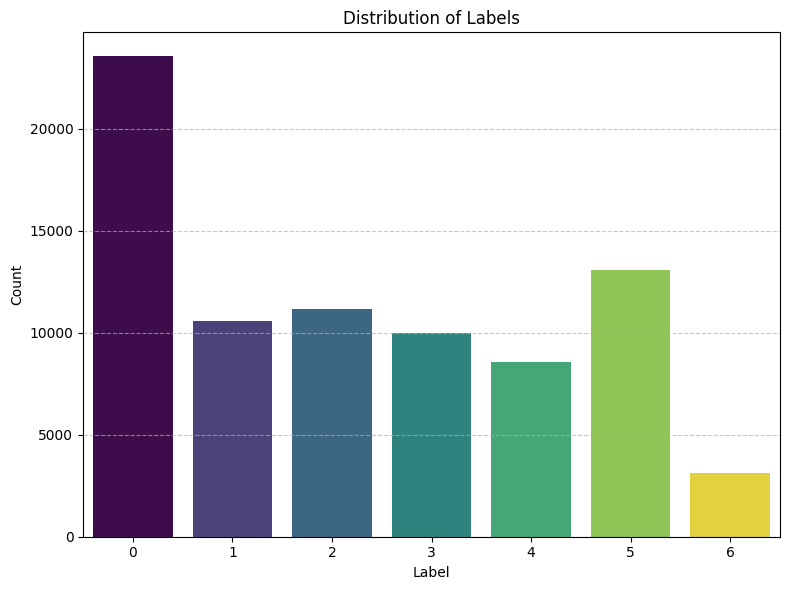

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis', hue=label_counts.index, legend=False)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
for col in df.columns:
  print(col,df[col].isna().sum())

Id 0
source 0
title 1
article 1
page_rank 0
timestamp 0
label 0


In [ ]:
print("Rows with missing 'title' values:")
display(df[df['title'].isna()])

print("\nRows with missing 'article' values:")
display(df[df['article'].isna()])

Rows with missing 'title' values:


,Id,source,title,article,page_rank,timestamp,label
26038,26038,Forbes,NaN,\N,5,2004-11-19 23:47:53,1



Rows with missing 'article' values:


,Id,source,title,article,page_rank,timestamp,label
53004,53004,CNET,"20,000 more H1-B visas",NaN,3,0000-00-00 00:00:00,2


In [ ]:
X, y = df.drop(columns=['label','Id']), df['label']

In [ ]:
def hour_extractor(X):
  temp_datetime = pd.to_datetime(X["timestamp"], errors='coerce')
  X["hour"] = temp_datetime.dt.hour
  imputer = SimpleImputer(strategy='most_frequent')
  X["hour"] = imputer.fit_transform(X[["hour"]])
  X["hour"] = X["hour"].astype(int)
  #X.drop(columns=['timestamp'],inplace=True)
  return X

def add_cyclic_hour(X):
    X = X.copy()
    X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
    return X
def data_extractor(X):
  X = X.copy()
  X["timestamp"] = pd.to_datetime(X["timestamp"], errors='coerce')
  X["timestamp"] = X["timestamp"].dt.strftime('%Y-%m-%d') # Format to YYYY-MM-DD string
  #X.drop(columns=['timestamp'],inplace=True)
  return X

In [ ]:
X = hour_extractor(X)
X = add_cyclic_hour(X)
X = data_extractor(X)

In [ ]:
features = FeatureUnion([
    ("word", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        max_features=30000,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,6),
        min_df=3,
        max_features=35000,
        sublinear_tf=True
    ))
])

In [ ]:
def convert_text(X,feature,source_weight=0,title_weight=0):
  X[feature] = (
      ("__source__" + X["source"].astype(str) + " ") * source_weight
      + (X["title"].fillna("") + " ")* title_weight
      + X["article"].fillna("")
  )
  X.drop(columns=['article'],inplace=True)
  if source_weight != 0:
    X.drop(columns=['source'],inplace=True)
  if title_weight != 0:
    X.drop(columns=['title'],inplace=True)
  return X

def build_text(X):
    return (
        X["title"].fillna("") + " " +
        X["article"].fillna("") + " " +
        X["source"].fillna("")
    )


In [ ]:
def F1_score(model,Xtrain,Xtest):
  print(f"for model {model} the F1 goes as following\n train f1:\n")
  print(f1_score(y_train,model.predict(Xtrain),average='macro'))
  print("test f1:\n")
  print(f1_score(y_test,model.predict(Xtest),average='macro'))

In [ ]:
for co in X.columns:
  print(co,X[co].dtype)

page_rank int64
timestamp object
hour int64
hour_sin float64
hour_cos float64
text object


In [ ]:
X = convert_text(X,'text',source_weight=3,title_weight=2)

In [ ]:
X['text'].isna().sum()

np.int64(0)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42,stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42,stratify=y_train)

In [ ]:
print(y_train.value_counts()/y_train.shape[0])
print(y_val.value_counts()/y_val.shape[0])

label
0    0.294286
5    0.163168
2    0.139521
1    0.132351
3    0.124711
4    0.107176
6    0.038787
Name: count, dtype: float64
label
0    0.294250
5    0.163125
2    0.139500
1    0.132375
3    0.124750
4    0.107250
6    0.038750
Name: count, dtype: float64


In [ ]:
len(X['timestamp'].unique())

578

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", features,"text"),
        #("time", OneHotEncoder(), ["hour"]), # Corrected: use MinMaxScaler() instead of minmax_scale()
        #("hour", "passthrough", ["hour_sin", "hour_cos"]),
        ("day",make_pipeline(SimpleImputer(strategy='most_frequent'),OneHotEncoder(handle_unknown='ignore')),["timestamp"]),
        ("pagerank", "passthrough", ["page_rank"])
    ]
)

In [ ]:
Xtrainpre = preprocessor.fit_transform(X_train)
X_testpre = preprocessor.transform(X_test)


In [ ]:
LGR = LogisticRegression(C=1,max_iter=1000,class_weight='balanced')

In [ ]:
LGR.fit(Xtrainpre,y_train)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000)

In [ ]:
F1_score(LGR,Xtrainpre,X_testpre)

for model LogisticRegression(C=1, class_weight='balanced', max_iter=1000) the F1 goes as following
 train f1:

0.8381138925497028
test f1:

0.7237704719182417


In [ ]:
class_weight = {
    0: 1.0,
    5: 1.34,
    2: 1.45,
    1: 1.49,
    3: 1.54,
    4: 1.65,
    6: 2.76
}


In [ ]:
LSVC = LinearSVC(C = 0.095,
    class_weight=class_weight, dual=False,
        max_iter=700)

In [ ]:
LSVC.fit(Xtrainpre,y_train)

LinearSVC(C=0.095,
          class_weight={0: 1.0, 1: 1.49, 2: 1.45, 3: 1.54, 4: 1.65, 5: 1.34,
                        6: 2.76},
          dual=False, max_iter=700)

In [ ]:
F1_score(LSVC,Xtrainpre,X_testpre)

for model LinearSVC(C=0.095,
          class_weight={0: 1.0, 1: 1.49, 2: 1.45, 3: 1.54, 4: 1.65, 5: 1.34,
                        6: 2.76},
          dual=False, max_iter=700) the F1 goes as following
 train f1:

0.8440766287096976
test f1:

0.7272043966739543


In [ ]:
f1_score(y_val,LSVC.predict(preprocessor.transform(X_val)),average='macro')

0.7219492017630262

In [ ]:
model_best = make_pipeline(
    preprocessor,
    LSVC
)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model_best,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("CV Macro-F1:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())


CV Macro-F1: [0.72069369 0.71928283 0.72288183 0.72082045 0.71745919]
Mean: 0.7202275977530224
Std: 0.001798351878207131


In [ ]:
params_LSVC = {
    "C" : [0.09, 0.1, 0.12, 0.15, 0.2],
    "class_weight" : ["balanced",class_weight],
    "dual" : [False],
    "max_iter" : [700,800,900,1000],
}

In [ ]:
scores_LSVC = []
for config in ParameterGrid(params_LSVC):
  LSVCtest = LinearSVC(**config)
  LSVCtest.fit(Xtrainpre,y_train)
  score = f1_score(y_test,LSVCtest.predict(preprocessor.transform(X_test)),average='macro')
  F1_score(LSVCtest,Xtrainpre,X_testpre)
  scores_LSVC.append((config,score))


for model LinearSVC(C=0.09, class_weight='balanced', dual=False, max_iter=700) the F1 goes as following
 train f1:

0.8198924187530449
test f1:

0.7272759975465976
for model LinearSVC(C=0.09, class_weight='balanced', dual=False, max_iter=800) the F1 goes as following
 train f1:

0.8198924187530449
test f1:

0.7272759975465976
for model LinearSVC(C=0.09, class_weight='balanced', dual=False, max_iter=900) the F1 goes as following
 train f1:

0.8198924187530449
test f1:

0.7272759975465976
for model LinearSVC(C=0.09, class_weight='balanced', dual=False) the F1 goes as following
 train f1:

0.8198924187530449
test f1:

0.7272759975465976
for model LinearSVC(C=0.09,
          class_weight={0: 1.0, 1: 1.49, 2: 1.45, 3: 1.54, 4: 1.65, 5: 1.34,
                        6: 2.76},
          dual=False, max_iter=700) the F1 goes as following
 train f1:

0.833463375137487
test f1:

0.7313947257314491
for model LinearSVC(C=0.09,
          class_weight={0: 1.0, 1: 1.49, 2: 1.45, 3: 1.54, 4: 1.65, 5: 

In [ ]:
best_config_score = max(scores_LSVC, key=lambda item: item[1])
best_config = best_config_score[0]
max_f1_score = best_config_score[1]
print("\nMaximum F1 Score and its corresponding configuration:")
print(f"  Max F1 Score: {max_f1_score}")
print(f"  Best Configuration: {best_config}")
LSVC_best = LinearSVC(**best_config)
LSVC_best.fit(Xtrainpre,y_train)


Maximum F1 Score and its corresponding configuration:
  Max F1 Score: 0.7313947257314491
  Best Configuration: {'C': 0.09, 'class_weight': {0: 1.0, 5: 1.34, 2: 1.45, 1: 1.49, 3: 1.54, 4: 1.65, 6: 2.76}, 'dual': False, 'max_iter': 700}


LinearSVC(C=0.09,
          class_weight={0: 1.0, 1: 1.49, 2: 1.45, 3: 1.54, 4: 1.65, 5: 1.34,
                        6: 2.76},
          dual=False, max_iter=700)

In [ ]:
SGD = SGDClassifier(
    loss="hinge",       # SVM
    class_weight="balanced",
    alpha=1e-5,
    max_iter=500,
    learning_rate="optimal",
    tol=1e-3
)


In [ ]:
SGD.fit(Xtrainpre,y_train)

SGDClassifier(alpha=1e-05, class_weight='balanced', max_iter=500)

In [ ]:
F1_score(SGD,Xtrainpre,X_testpre)

for model SGDClassifier(alpha=1e-05, class_weight='balanced', max_iter=500) the F1 goes as following
 train f1:

0.9151723954840439
test f1:

0.7111675457307927


In [ ]:
params_SGD = {
    "alpha" : [1e-4,1e-3,1e-2],
    "loss" : ["hinge"],
    "class_weight" : ["balanced",None],
    "max_iter" : [200,300,500,1000],
    "learning_rate" : ["optimal"],
    "tol": [1e-4,1e-3,1e-2],
    "n_jobs": [-1]
    }

In [ ]:
Scors = []
for config in ParameterGrid(params_SGD):
  SGDtest = SGDClassifier(**config)
  SGDtest.fit(Xtrainpre,y_train)
  score = f1_score(y_test,SGDtest.predict(preprocessor.transform(X_test)),average='macro')
  F1_score(SGDtest)
  Scors.append((config,score))

for model SGDClassifier(class_weight='balanced', max_iter=200, n_jobs=-1, tol=0.0001) the F1 goes as following
 train f1:

0.7244872783213453
test f1:

0.6485937175852035
for model SGDClassifier(class_weight='balanced', max_iter=200, n_jobs=-1) the F1 goes as following
 train f1:

0.7242304195266297
test f1:

0.6490616552601812
for model SGDClassifier(class_weight='balanced', max_iter=200, n_jobs=-1, tol=0.01) the F1 goes as following
 train f1:

0.7214623049885007
test f1:

0.6478667372090632
for model SGDClassifier(class_weight='balanced', max_iter=300, n_jobs=-1, tol=0.0001) the F1 goes as following
 train f1:

0.7244938143162588
test f1:

0.6478660102259697
for model SGDClassifier(class_weight='balanced', max_iter=300, n_jobs=-1) the F1 goes as following
 train f1:

0.7236013536545219
test f1:

0.6485532217992986
for model SGDClassifier(class_weight='balanced', max_iter=300, n_jobs=-1, tol=0.01) the F1 goes as following
 train f1:

0.7236136282504201
test f1:

0.6491640117768437
fo

In [ ]:
best_config_score = max(Scors, key=lambda item: item[1])
best_config = best_config_score[0]
max_f1_score = best_config_score[1]
print("\nMaximum F1 Score and its corresponding configuration:")
print(f"  Max F1 Score: {max_f1_score}")
print(f"  Best Configuration: {best_config}")


Maximum F1 Score and its corresponding configuration:
  Max F1 Score: 0.6505005423328333
  Best Configuration: {'alpha': 0.0001, 'class_weight': 'balanced', 'learning_rate': 'optimal', 'loss': 'hinge', 'max_iter': 1000, 'n_jobs': -1, 'tol': 0.001}


In [ ]:
svm = CalibratedClassifierCV(
    LinearSVC(
        C = 0.1,
        class_weight="balanced",
        dual=False,
        max_iter=3000
    ),
    cv=3
)

In [ ]:
sgd = SGDClassifier(
    loss="log_loss",       # SVM
    class_weight="balanced",
    alpha=1e-4,
    max_iter=1000,
)

In [ ]:
ensemble = VotingClassifier(
    estimators=[
        ("svm", svm),
        ("sgd", sgd)
    ],
    voting="soft"
)

In [ ]:
ensemble.fit(Xtrainpre,y_train)

VotingClassifier(estimators=[('svm',
                              CalibratedClassifierCV(cv=3,
                                                     estimator=LinearSVC(C=0.1,
                                                                         class_weight='balanced',
                                                                         dual=False,
                                                                         max_iter=3000))),
                             ('sgd',
                              SGDClassifier(class_weight='balanced',
                                            loss='log_loss'))],
                 voting='soft')

In [ ]:
F1_score(ensemble)

for model VotingClassifier(estimators=[('svm',
                              CalibratedClassifierCV(cv=3,
                                                     estimator=LinearSVC(C=0.1,
                                                                         class_weight='balanced',
                                                                         dual=False,
                                                                         max_iter=3000))),
                             ('sgd',
                              SGDClassifier(class_weight='balanced',
                                            loss='log_loss'))],
                 voting='soft') the F1 goes as following
 train f1:

0.7775717782264142
test f1:

0.7083141713808278


In [ ]:
X_train_txt = preprocessor.transform(X_train)
X_test_txt = preprocessor.transform(X_test)

In [ ]:
dfeval = hour_extractor(dfeval)
dfeval = add_cyclic_hour(dfeval)

In [ ]:
dfeval = convert_text(dfeval,'text',source_weight=3,title_weight=2)

In [ ]:
dfeval.columns

Index(['Id', 'page_rank', 'hour', 'hour_sin', 'hour_cos', 'text'], dtype='object')

In [ ]:
model_best.fit(X,y)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('text',
                                                  FeatureUnion(transformer_list=[('word',
                                                                                  TfidfVectorizer(max_df=0.9,
                                                                                                  max_features=30000,
                                                                                                  min_df=3,
                                                                                                  ngram_range=(1,
                                                                                                               2),
                                                                                                  sublinear_tf=True)),
                                                                                 ('char',
                                                                                  TfidfVectorizer(analyzer='char_wb',
                                                                                                  max_features=35000,
                                                                                                  min_df=3,
                                                                                                  ngram_range=(3,
                                                                                                               6),
                                                                                                  sublinear_tf=True))]),
                                                  'text'),
                                                 ('hour', 'passthrough',
                                                  ['hour_sin', 'hour_cos']),
                                                 ('pagerank', 'passthrough',
                                                  ['page_rank'])])),
                ('linearsvc',
                 LinearSVC(C=0.095,
                           class_weight={0: 1.0, 1: 1.49, 2: 1.45, 3: 1.54,
                                         4: 1.65, 5: 1.34, 6: 2.76},
                           dual=False, max_iter=700))])

In [ ]:
ypred = model_best.predict(dfeval)

In [ ]:
pd.DataFrame({
    "Id" : range(len(ypred)),
    "Predicted" : ypred
}).to_csv("final_output.csv",index = False)